# **Airbnb Analysis**
This document will serve a guide on Fundamentals for Pandas and Data Analysis

**Import libraries** :\
The first step, even before importing datasets, is to import the relevant libraries you are going to use. For this, you need too think about what kind analysis you are planning to do, before even inspecting your data.

In [1]:
#An important note is to save libraries as they're conventionally shortened. For example: pandas as pd
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

### Create Test Objects

In [2]:
my_list = [1,2,3,4,5]

df = pd.DataFrame(np.random.rand(20,5)) # Creates 5 columns and 20 rows of random floats
pd.Series(my_list) # Create a series from iterable my_list
df.index = pd.date_range('1900/1/30', periods= df.shape[0])

In [3]:
df.head()

,0,1,2,3,4
1900-01-30,0.719034,0.584900,0.689365,0.743670,0.863563
1900-01-31,0.790357,0.040966,0.154280,0.578654,0.646611
1900-02-01,0.800955,0.670144,0.731621,0.510269,0.235446
1900-02-02,0.212320,0.881368,0.096227,0.155971,0.574582
1900-02-03,0.453572,0.993457,0.317443,0.987867,0.406303


## Manipulating data - fundamentals

Big disclaimer, in order to use Drive as your source, you need to allow Google Colab to access to your files:

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


**Import data and inspect it** :\
A nice approach to start your analysis is to take a quick look in a whole picture of data. Then, you will be able to decide which may be the data drivers that will lead your analysis.

In [5]:
# pd.read_csv  is the most common instruction for importind data sets from .csv's files. ''.read' varieties allows
# other type of files

# Big note
data = pd.read_csv('/content/drive/MyDrive/Colab_Notebooks/MachineLearning_FJ26/1_EDA/listings.csv')
# path = '/content/drive/MyDrive/Colab_Notebooks/MachineLearning_FJ26/1_EDA/listings.csv'

## Inspecting Data

In [6]:
# To inspect the variables, firts we take a big look at the dataset
data.head()
# Hint: print() command consume a lot of resourcers, so running the variable alone in the shell, is way better in all aspects

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.23,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,43,2019-01-02,0.38,2,365
2,3330,++ Brooklyn Penthouse Guestroom ++,4177,Jbee,Brooklyn,Williamsburg,40.70856,-73.94236,Private room,70,5,39,2018-12-07,0.35,3,217
3,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
4,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,239,2019-03-03,4.43,1,164


In [7]:
#To inspect the first fows of the Dataframe
data.tail()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
49743,32848199,"Cozy, Confortable and Nice place in Bay Ridge",246910562,Stefany,Brooklyn,Bay Ridge,40.63114,-74.02529,Private room,53,1,0,NaN,NaN,1,174
49744,32849284,Chic Studio in Williamsburg,6657574,Gene,Brooklyn,Williamsburg,40.71262,-73.95842,Entire home/apt,149,2,0,NaN,NaN,3,346
49745,32849527,Designer Apt Next 538 acres Park Near JFK and LG,151282236,Sigrid,Queens,Richmond Hill,40.70162,-73.84071,Entire home/apt,95,1,0,NaN,NaN,1,79
49746,32850062,Master Bedroom for 3 guests heart of East Vill...,95892016,Leonora,Manhattan,Stuyvesant Town,40.73008,-73.97776,Private room,150,1,0,NaN,NaN,7,104
49747,32858895,Live like a true New Yorker!,8454981,Artez,Manhattan,Hell's Kitchen,40.75711,-73.99796,Entire home/apt,150,3,0,NaN,NaN,1,47


In [8]:
#To inspect the n last rows of the DataFrame
data.tail()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
49743,32848199,"Cozy, Confortable and Nice place in Bay Ridge",246910562,Stefany,Brooklyn,Bay Ridge,40.63114,-74.02529,Private room,53,1,0,NaN,NaN,1,174
49744,32849284,Chic Studio in Williamsburg,6657574,Gene,Brooklyn,Williamsburg,40.71262,-73.95842,Entire home/apt,149,2,0,NaN,NaN,3,346
49745,32849527,Designer Apt Next 538 acres Park Near JFK and LG,151282236,Sigrid,Queens,Richmond Hill,40.70162,-73.84071,Entire home/apt,95,1,0,NaN,NaN,1,79
49746,32850062,Master Bedroom for 3 guests heart of East Vill...,95892016,Leonora,Manhattan,Stuyvesant Town,40.73008,-73.97776,Private room,150,1,0,NaN,NaN,7,104
49747,32858895,Live like a true New Yorker!,8454981,Artez,Manhattan,Hell's Kitchen,40.75711,-73.99796,Entire home/apt,150,3,0,NaN,NaN,1,47


In [9]:
#To inspect the size of the dataframe
data.shape

(49748, 16)

In [10]:
#To have a better understanding of the index, datatypes and memory information:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49748 entries, 0 to 49747
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              49748 non-null  int64  
 1   name                            49731 non-null  object 
 2   host_id                         49748 non-null  int64  
 3   host_name                       49740 non-null  object 
 4   neighbourhood_group             49748 non-null  object 
 5   neighbourhood                   49748 non-null  object 
 6   latitude                        49748 non-null  float64
 7   longitude                       49748 non-null  float64
 8   room_type                       49748 non-null  object 
 9   price                           49748 non-null  int64  
 10  minimum_nights                  49748 non-null  int64  
 11  number_of_reviews               49748 non-null  int64  
 12  last_review                     

In [11]:
#To do a quick count referencing an specific column, use value_counts(). Dropna prevents Python from removing null rows
data['neighbourhood_group'].value_counts(dropna=False)

,count
neighbourhood_group,
Manhattan,22559
Brooklyn,20312
Queens,5525
Bronx,1001
Staten Island,351


In [12]:
#Get the basis statistics of your dataframe
data.describe()

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,4.974800e+04,4.974800e+04,49748.000000,49748.000000,49748.000000,49748.000000,49748.000000,39260.000000,49748.000000,49748.000000
mean,1.738967e+07,6.058319e+07,40.729299,-73.953238,150.931796,7.064284,22.244894,1.300503,5.742261,118.296193
std,9.816381e+06,6.951425e+07,0.053860,0.044968,225.025933,20.481797,41.954729,1.563485,20.767163,134.379128
min,2.539000e+03,2.571000e+03,40.499790,-74.242850,0.000000,1.000000,0.000000,0.010000,1.000000,0.000000
25%,9.004913e+06,7.426523e+06,40.690750,-73.983500,69.000000,1.000000,1.000000,0.207500,1.000000,0.000000
50%,1.834661e+07,2.899476e+07,40.723670,-73.956450,107.000000,2.000000,5.000000,0.670000,1.000000,61.000000
75%,2.609943e+07,9.698084e+07,40.763130,-73.937530,175.000000,5.000000,23.000000,1.910000,2.000000,239.000000
max,3.285890e+07,2.471184e+08,40.911690,-73.712990,10000.000000,1250.000000,588.000000,19.360000,192.000000,365.000000


## Data Selection

In [13]:
#Returns column with the label selected. (In this case label is col as a Series)
data['latitude']

,latitude
0,40.64749
1,40.75362
2,40.70856
3,40.80902
4,40.68514
...,...
49743,40.63114
49744,40.71262
49745,40.70162
49746,40.73008


In [14]:
#You can temporarily or permanently short dataframes as:
data[['neighbourhood','latitude']]

,neighbourhood,latitude
0,Kensington,40.64749
1,Midtown,40.75362
2,Williamsburg,40.70856
3,Harlem,40.80902
4,Clinton Hill,40.68514
...,...,...
49743,Bay Ridge,40.63114
49744,Williamsburg,40.71262
49745,Richmond Hill,40.70162
49746,Stuyvesant Town,40.73008


In [15]:
#You can inspect a series (or columns) by position or by index:
data.neighbourhood.iloc[0]

'Kensington'

In [16]:
#Here is an example of selection by index:
data.neighbourhood.loc[0]

'Kensington'

In [17]:
#You can inspect the values of the first row (position 0) with .loc and series method
data.iloc[10,:]

,10
id,5216
name,Super Large APT
host_id,7510
host_name,Tonya
neighbourhood_group,Manhattan
neighbourhood,Flatiron District
latitude,40.74357
longitude,-73.98999
room_type,Entire home/apt
price,126


In [18]:
#Or just the value inf the first columns and firts rows, for example
data.iloc[0,0]

np.int64(2539)

## Data Cleaning

In [19]:
#You may drop the null values in a dataframe with:

print(data.shape)
len(data['name'].dropna())

(49748, 16)


49731

In [20]:
#An you may even fill your null values with:
print(data.shape)
len(data['name'].fillna(' '))

(49748, 16)


49748

In [21]:
#Don't worry if you didn't save your results into a new or old variable, this methods will not be permanent
print("The amount of not null values in column name is:", len(data['name'].dropna()))

The amount of not null values in column name is: 49731


In [22]:
#The easiest way of droppin duplicates is with:
print("The amount of unique owners of AirBnb is:")
print(len(data.drop_duplicates(subset='name')))

The amount of unique owners of AirBnb is:
48608


In [23]:
#Let's go back into our sampled dataframe. You may rename the columns with next method

print("Columns are saved as integer range numbers: ", df.columns)
print("You may change that with df.rename")
df.rename(columns={0:'Column1',1:'Column2',2:'Column3',3:'Columns4',4:'Column5'})


Columns are saved as integer range numbers:  RangeIndex(start=0, stop=5, step=1)
You may change that with df.rename


,Column1,Column2,Column3,Columns4,Column5
1900-01-30,0.719034,0.584900,0.689365,0.743670,0.863563
1900-01-31,0.790357,0.040966,0.154280,0.578654,0.646611
1900-02-01,0.800955,0.670144,0.731621,0.510269,0.235446
1900-02-02,0.212320,0.881368,0.096227,0.155971,0.574582
1900-02-03,0.453572,0.993457,0.317443,0.987867,0.406303
1900-02-04,0.703070,0.725795,0.699821,0.903450,0.283668
1900-02-05,0.028506,0.860142,0.047568,0.148154,0.047298
1900-02-06,0.176129,0.427100,0.850852,0.867402,0.632214
1900-02-07,0.266807,0.398805,0.927020,0.275424,0.870902
1900-02-08,0.743703,0.953883,0.898316,0.337781,0.457196


## Descriptive Analysis

Size of the arrange, as shown, is of 16 variables, and almost 50 k entries.\
Next step will be to determine the type of data for each camp.

In [24]:
#To know the type of information from your dataset, instruction .info() will be run
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49748 entries, 0 to 49747
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              49748 non-null  int64  
 1   name                            49731 non-null  object 
 2   host_id                         49748 non-null  int64  
 3   host_name                       49740 non-null  object 
 4   neighbourhood_group             49748 non-null  object 
 5   neighbourhood                   49748 non-null  object 
 6   latitude                        49748 non-null  float64
 7   longitude                       49748 non-null  float64
 8   room_type                       49748 non-null  object 
 9   price                           49748 non-null  int64  
 10  minimum_nights                  49748 non-null  int64  
 11  number_of_reviews               49748 non-null  int64  
 12  last_review                     

First line show that data is read as a **data.frame**\
Number of entries and columns, as stated before is: **49748** & **16**  respectively\
For every entry, the type of data is displayed. Object types such as "neighbourhood_type" might be changed later.\
last_review & reviews_per_month have NA data, which later will be fixed, if information is relevant.


### Descriptive Analysis
For the descriptive analysis columns are inspected in order to decide which camps are useful.

In [25]:
#Fist eliminate the null data rows
nnadata=data.dropna(axis=0, how="all")

In [26]:
nnadata.shape

(49748, 16)

Then, the column with the names is irrelevant for the primary analysis

In [27]:
ncol = data.drop(columns="host_name")

In [28]:
ncol.shape

(49748, 15)

After this, it seems reasonable to divide the sectors into neighboorhood to watch de geographical differences

In [29]:
Manhattan = ncol[ncol.neighbourhood_group =='Manhattan']
Brooklyn = ncol[ncol.neighbourhood_group =='Brooklyn']
Queens = ncol[ncol.neighbourhood_group =='Queens']
Bronx = ncol[ncol.neighbourhood_group =='Bronx']
StatenIsland = data[data.neighbourhood_group =='Staten Island']

After this, a quick inspection will be performed to see the general structure of the data

In [30]:
def Neigh(rows):
    return len(rows)

NG = ncol.groupby('neighbourhood_group').apply(Neigh)
NG

/tmp/ipykernel_2067/1274115488.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  NG = ncol.groupby('neighbourhood_group').apply(Neigh)


,0
neighbourhood_group,
Bronx,1001
Brooklyn,20312
Manhattan,22559
Queens,5525
Staten Island,351


Text(0, 0.5, 'Neighborhoods')

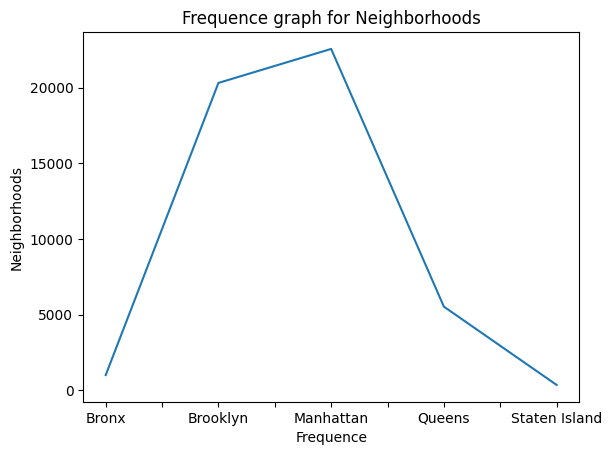

In [31]:
NG.plot()
plt.title('Frequence graph for Neighborhoods')
plt.xlabel("Frequence")
plt.ylabel("Neighborhoods")

## Roadpmap to analize any dataset

In [32]:
data

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.23,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,43,2019-01-02,0.38,2,365
2,3330,++ Brooklyn Penthouse Guestroom ++,4177,Jbee,Brooklyn,Williamsburg,40.70856,-73.94236,Private room,70,5,39,2018-12-07,0.35,3,217
3,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
4,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,239,2019-03-03,4.43,1,164
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49743,32848199,"Cozy, Confortable and Nice place in Bay Ridge",246910562,Stefany,Brooklyn,Bay Ridge,40.63114,-74.02529,Private room,53,1,0,NaN,NaN,1,174
49744,32849284,Chic Studio in Williamsburg,6657574,Gene,Brooklyn,Williamsburg,40.71262,-73.95842,Entire home/apt,149,2,0,NaN,NaN,3,346
49745,32849527,Designer Apt Next 538 acres Park Near JFK and LG,151282236,Sigrid,Queens,Richmond Hill,40.70162,-73.84071,Entire home/apt,95,1,0,NaN,NaN,1,79
49746,32850062,Master Bedroom for 3 guests heart of East Vill...,95892016,Leonora,Manhattan,Stuyvesant Town,40.73008,-73.97776,Private room,150,1,0,NaN,NaN,7,104


In [33]:
#Verify the first values and visualize your dataset
data.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.23,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,43,2019-01-02,0.38,2,365
2,3330,++ Brooklyn Penthouse Guestroom ++,4177,Jbee,Brooklyn,Williamsburg,40.70856,-73.94236,Private room,70,5,39,2018-12-07,0.35,3,217
3,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
4,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,239,2019-03-03,4.43,1,164


In [34]:
#Summarize the content of the columns
print(data.info())
print('''
Heres is an statistical description of the dataset, for its numeric columns:
''')
data.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49748 entries, 0 to 49747
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              49748 non-null  int64  
 1   name                            49731 non-null  object 
 2   host_id                         49748 non-null  int64  
 3   host_name                       49740 non-null  object 
 4   neighbourhood_group             49748 non-null  object 
 5   neighbourhood                   49748 non-null  object 
 6   latitude                        49748 non-null  float64
 7   longitude                       49748 non-null  float64
 8   room_type                       49748 non-null  object 
 9   price                           49748 non-null  int64  
 10  minimum_nights                  49748 non-null  int64  
 11  number_of_reviews               49748 non-null  int64  
 12  last_review                     

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,4.974800e+04,4.974800e+04,49748.000000,49748.000000,49748.000000,49748.000000,49748.000000,39260.000000,49748.000000,49748.000000
mean,1.738967e+07,6.058319e+07,40.729299,-73.953238,150.931796,7.064284,22.244894,1.300503,5.742261,118.296193
std,9.816381e+06,6.951425e+07,0.053860,0.044968,225.025933,20.481797,41.954729,1.563485,20.767163,134.379128
min,2.539000e+03,2.571000e+03,40.499790,-74.242850,0.000000,1.000000,0.000000,0.010000,1.000000,0.000000
25%,9.004913e+06,7.426523e+06,40.690750,-73.983500,69.000000,1.000000,1.000000,0.207500,1.000000,0.000000
50%,1.834661e+07,2.899476e+07,40.723670,-73.956450,107.000000,2.000000,5.000000,0.670000,1.000000,61.000000
75%,2.609943e+07,9.698084e+07,40.763130,-73.937530,175.000000,5.000000,23.000000,1.910000,2.000000,239.000000
max,3.285890e+07,2.471184e+08,40.911690,-73.712990,10000.000000,1250.000000,588.000000,19.360000,192.000000,365.000000


In [35]:
#Null verification
print(data.isnull().sum())

id                                    0
name                                 17
host_id                               0
host_name                             8
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10488
reviews_per_month                 10488
calculated_host_listings_count        0
availability_365                      0
dtype: int64


In [36]:
data.columns

Index(['id', 'name', 'host_id', 'host_name', 'neighbourhood_group',
       'neighbourhood', 'latitude', 'longitude', 'room_type', 'price',
       'minimum_nights', 'number_of_reviews', 'last_review',
       'reviews_per_month', 'calculated_host_listings_count',
       'availability_365'],
      dtype='object')

In [37]:
#Nomenclatura para llamar a a una columna
# Nombre_de_dataframe['nombre de la columna´]
data['name']

,name
0,Clean & quiet apt home by the park
1,Skylit Midtown Castle
2,++ Brooklyn Penthouse Guestroom ++
3,THE VILLAGE OF HARLEM....NEW YORK !
4,Cozy Entire Floor of Brownstone
...,...
49743,"Cozy, Confortable and Nice place in Bay Ridge"
49744,Chic Studio in Williamsburg
49745,Designer Apt Next 538 acres Park Near JFK and LG
49746,Master Bedroom for 3 guests heart of East Vill...


In [38]:
#Choose the treatment for null values
data['name'].fillna('No name', inplace=True) # Replace null values with "No name" string
data['host_name'].fillna('No host name', inplace=True) #Replace null values with "No host name" string

data['reviews_per_month'].fillna(0, inplace=True) #Fill the NaN values with 0s for missing information

#Convierte los valores a fechas
data['last_review'] = pd.to_datetime(data['last_review']) #Transform last_review column into datetime

/tmp/ipykernel_2067/2499815642.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['host_name'].fillna('No host name', inplace=True) #Replace null values with "No host name" string
/tmp/ipykernel_2067/2499815642.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, 

In [39]:
#Null verification
print(data.isnull().sum())

id                                    0
name                                  0
host_id                               0
host_name                             0
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10488
reviews_per_month                     0
calculated_host_listings_count        0
availability_365                      0
dtype: int64


In [40]:
#For example, what is the max price, the mix price, median price or the average price for rooms:
print("Max price is:", data['price'].max())

print("Min price is:", data['price'].min())

print("Min price is without 0's:", data[data['price']>0]['price'].min())

print("The median prices without 0's:", data[data['price']>0]['price'].median())

print("The median is:", data['price'].median())

print("Average price is", round(data[data['price']>0]['price'].mean(),2))
print("Average price is", round(data['price'].mean(),2))


Max price is: 10000
Min price is: 0
Min price is without 0's: 10
The median prices without 0's: 107.0
The median is: 107.0
Average price is 150.98
Average price is 150.93


In [63]:
#How about understanding which is the most common neighbourhood in the dataframe. For this, use method mode()
print(data['neighbourhood_group'].mode())

0    Manhattan
Name: neighbourhood_group, dtype: object


In [45]:
data2 = pd.DataFrame({'numeros':['uno','uno','dos','dos']})
print(data2['numeros'].mode()[1])

uno


In [64]:
data['neighbourhood_group'].value_counts()

,count
neighbourhood_group,
Manhattan,22559
Brooklyn,20312
Queens,5525
Bronx,1001
Staten Island,351


In [65]:
#How may you know how many rooms are below 200 USD the night, but not 0?
data[(data['price'] < 200) & (data['price']>0)].shape[0]

39916

In [66]:
#If haven't done so far, import seaborn and matplotlit. These libraries are key to explore big datasets
import matplotlib.pyplot as plt
import seaborn as sns

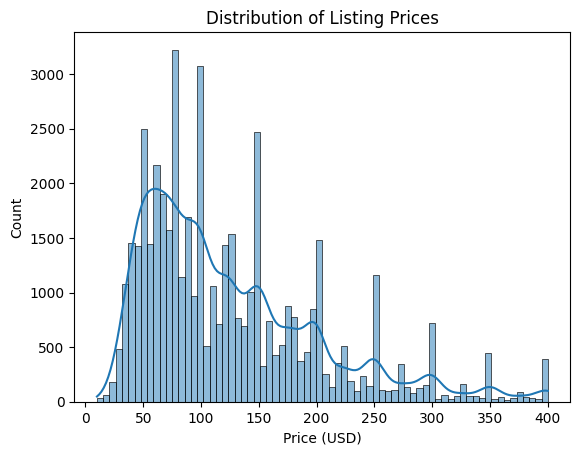

In [75]:
#Generate and histogram to analize AirBnB prices
temp_data = data[(data['price'] < 401) & (data['price']>0)] #Filtro los datos entre 0 y 400. Se guarda una base de datos más pequeña

sns.histplot(temp_data['price'], kde=True) #Genera la gráfica
#sns.histplot(data['price'], kde=True) #Genera la gráfica
#sns.histplot(np.log(data['price']), kde=True)
plt.title('Distribution of Listing Prices') #Modifico para poner el título
plt.xlabel('Price (USD)') #Modifico para poner el título del eye x
plt.ylabel('Count') # Modifico para poner el título del eye y
plt.show() #Muestra la gráfica.

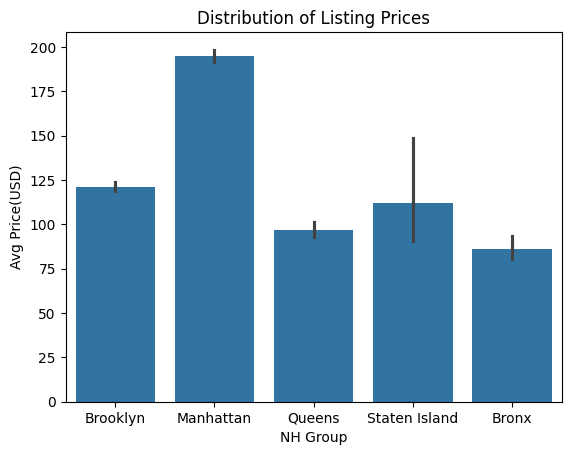

In [78]:
#Let's analyze average prices by neighbourhood_group. For this, we can use barplot, which automatically groups by average price

sns.barplot(x=data['neighbourhood_group'], y=data['price'])
#sns.histplot(np.log(data['price']), kde=True)
plt.title('Distribution of Listing Prices')
plt.xlabel('NH Group')
plt.ylabel('Avg Price(USD)')
plt.show()

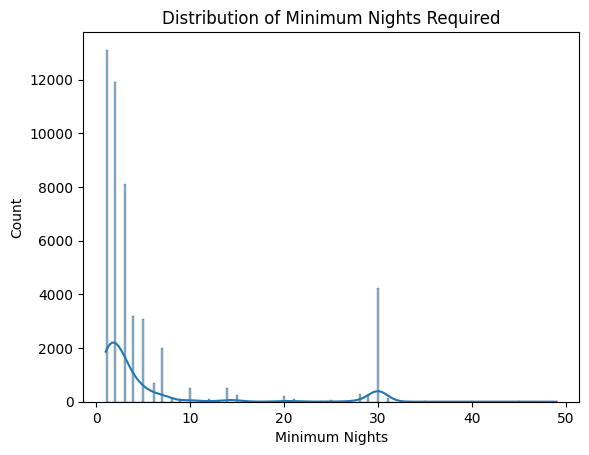

In [79]:
#Let's now explore minumum nights for example
#sns.histplot(np.log(data['minimum_nights']+1), kde=True)

temp_data = data[(data['minimum_nights'] < 50) & (data['minimum_nights']>0)]

sns.histplot(temp_data['minimum_nights'], kde=True)

#sns.histplot(temp_data['minimum_nights'], kde=True)
plt.title('Distribution of Minimum Nights Required')
plt.xlabel('Minimum Nights')
plt.ylabel('Count')
plt.show()

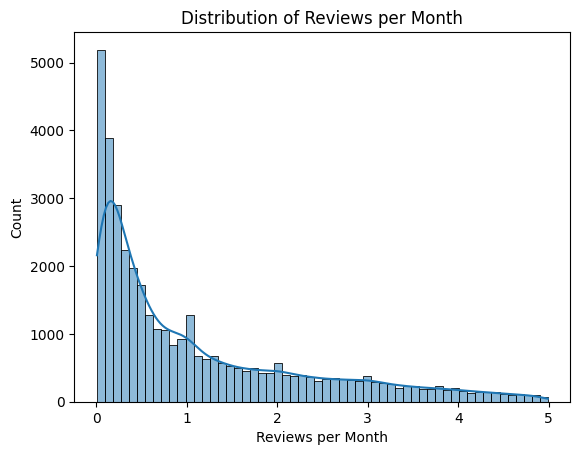

In [80]:
#Let's explore the monthly reviews:
temp_data = data[(data['reviews_per_month'] < 5) & (data['reviews_per_month']>0)]

sns.histplot(temp_data['reviews_per_month'], kde=True)
plt.title('Distribution of Reviews per Month')
plt.xlabel('Reviews per Month')
plt.ylabel('Count')
plt.show()

In [81]:
#A common idea is to think that price is usually related with availability. Let's check it out.
correlation = data['price'].corr(data['availability_365'])
print(correlation)

0.08045356216075125


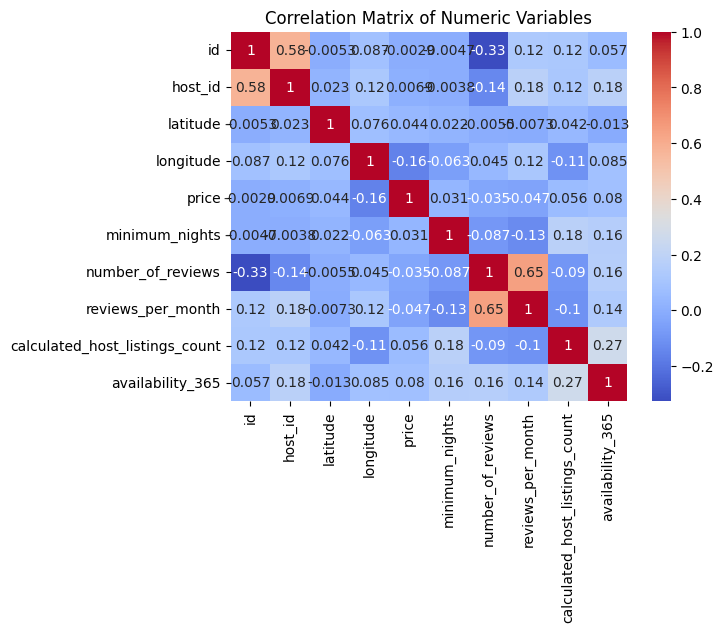

In [82]:
#We can even generate correlation matrixes to see how variables are related
# Filter just numeric values
numeric_data = data.select_dtypes(include=['int64', 'float64'])

correlation_matrix = numeric_data.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix of Numeric Variables')
plt.show()

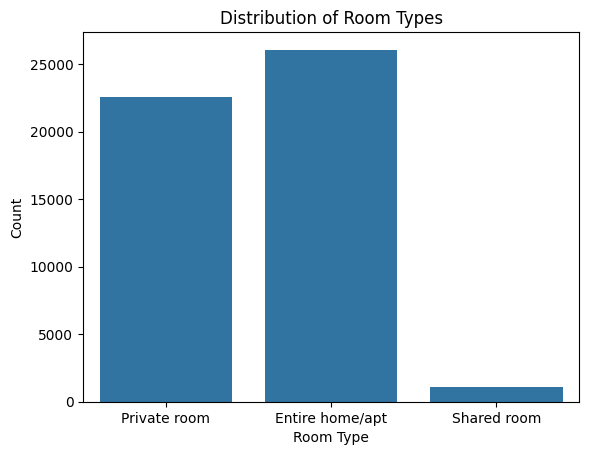

In [55]:
#Explore de distribution of room types:
#sns.countplot(x='room_type', data=data)
sns.countplot(x = data['room_type'])
plt.title('Distribution of Room Types')
plt.xlabel('Room Type')
plt.ylabel('Count')
plt.show()

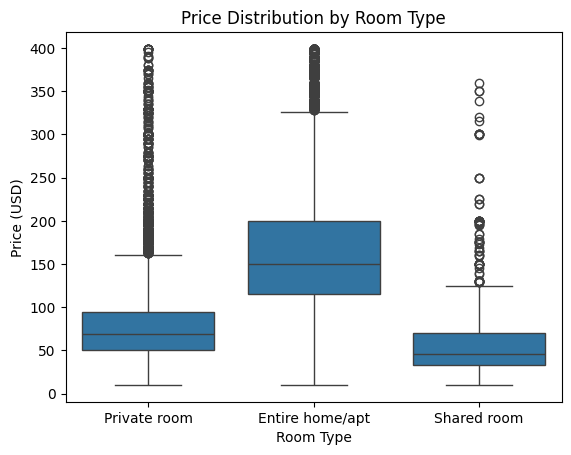

In [56]:
#And the relationship of roomtype and prices:
temp_data = data[(data['price'] < 400) & (data['price']>0)]
#sns.boxplot(x='room_type', y='price', data=temp_data)
sns.boxplot(x = temp_data['room_type'], y =temp_data['price'])
#sns.boxplot(x = data['room_type'], y = np.log(data['price']+1))
plt.title('Price Distribution by Room Type')
plt.xlabel('Room Type')
plt.ylabel('Price (USD)')
plt.show()

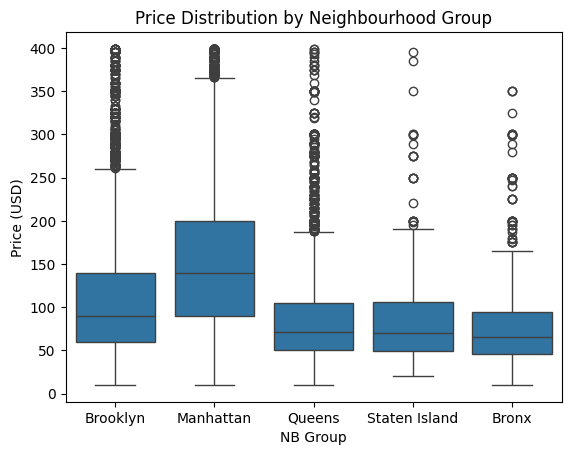

In [57]:
#Explore how is the distribution of roomtypes/prices from neighborhood_group
sns.boxplot(x='neighbourhood_group', y='price', data=temp_data)
#sns.boxplot(x=data['neighbourhood_group'], y = np.log(data['price']+1))
plt.title('Price Distribution by Neighbourhood Group')
plt.xlabel('NB Group')
plt.ylabel('Price (USD)')
plt.show()

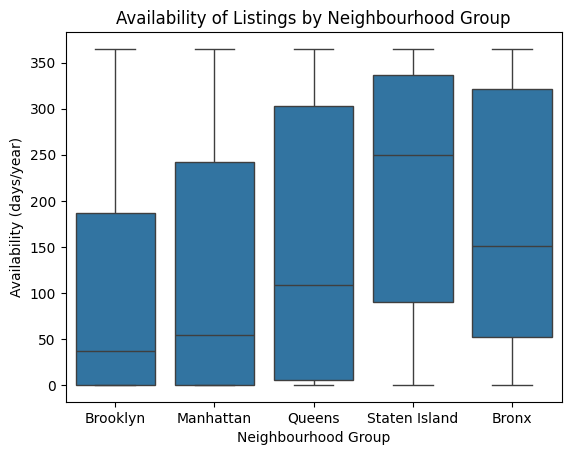

In [58]:
#How is availability through the year?
sns.boxplot(x='neighbourhood_group', y='availability_365', data=data)
plt.title('Availability of Listings by Neighbourhood Group')
plt.xlabel('Neighbourhood Group')
plt.ylabel('Availability (days/year)')
plt.show()

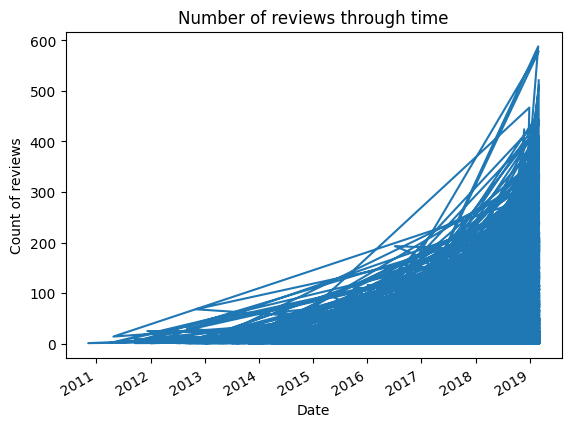

In [59]:
#Analyze the number_of_reviews through time
data.set_index('last_review')['number_of_reviews'].plot()
plt.title('Number of reviews through time')
plt.xlabel('Date')
plt.ylabel('Count of reviews')
plt.show()

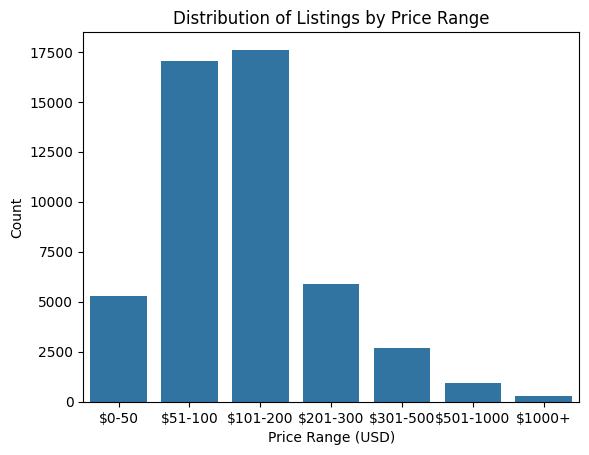

In [60]:
#Actually there is a better way of vizualiting data. Let's do buckets of grouped data.
bins_price = [0, 50, 100, 200, 300, 500, 1000, 5000]
labels_price = ['$0-50', '$51-100', '$101-200', '$201-300', '$301-500', '$501-1000', '$1000+']
data['price_bucket'] = pd.cut(data['price'], bins=bins_price, labels=labels_price, right=False)

sns.countplot(x='price_bucket', data=data)
plt.title('Distribution of Listings by Price Range')
plt.xlabel('Price Range (USD)')
plt.ylabel('Count')
plt.show()

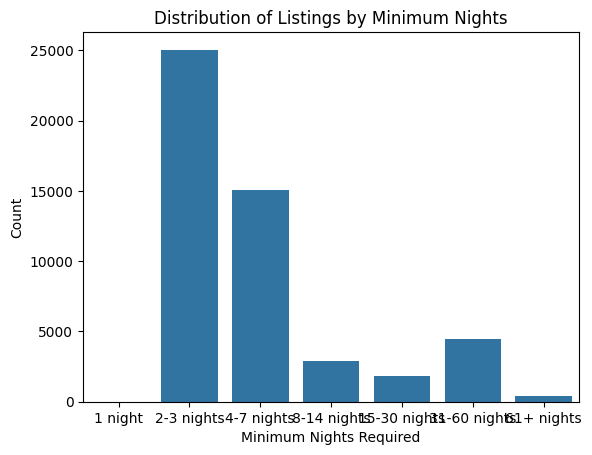

In [61]:
#SAme thing with minimum nights
bins_nights = [0, 1, 3, 7, 14, 30, 60, 365]
labels_nights = ['1 night', '2-3 nights', '4-7 nights', '8-14 nights', '15-30 nights', '31-60 nights', '61+ nights']
data['nights_bucket'] = pd.cut(data['minimum_nights'], bins=bins_nights, labels=labels_nights, right=False)

sns.countplot(x='nights_bucket', data=data)
plt.title('Distribution of Listings by Minimum Nights')
plt.xlabel('Minimum Nights Required')
plt.ylabel('Count')
plt.show()

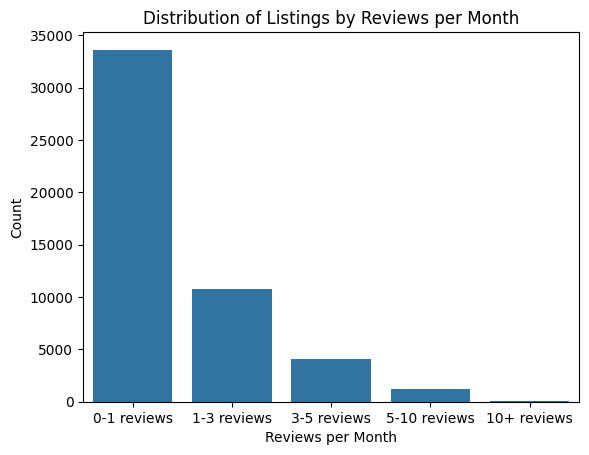

In [62]:
#And for the count of rreviews
bins_reviews = [0, 1, 3, 5, 10, 20]
labels_reviews = ['0-1 reviews', '1-3 reviews', '3-5 reviews', '5-10 reviews', '10+ reviews']
data['reviews_bucket'] = pd.cut(data['reviews_per_month'], bins=bins_reviews, labels=labels_reviews, right=False)

sns.countplot(x='reviews_bucket', data=data)
plt.title('Distribution of Listings by Reviews per Month')
plt.xlabel('Reviews per Month')
plt.ylabel('Count')
plt.show()